In [8]:
##This has to be ran from parent directoty otherwise functions.func does not exist 

import xarray as xr 
import functions.funcs as funcs
import functions.plotting as plot
import matplotlib.pyplot as plt 
import geopandas as gpd
import pandas as pd
import numpy as np

### First test with CMEMS data 

- tests working with cmems data
- shows mean flow of CMEMS
- compairs to dFAD mean flow

In [9]:
ds = xr.open_dataset(r"Data\cmems.nc")
winds = xr.open_dataset(r"Data\ERA5_10m_winds.nc")

In [10]:
winds.lat.values

array([8.  , 7.75, 7.5 , 7.25, 7.  , 6.75, 6.5 , 6.25, 6.  , 5.75, 5.5 ,
       5.25, 5.  , 4.75, 4.5 , 4.25])

In [11]:
vo  = ds['vo'] ## this is y velocity
uo = ds['uo'] ## this is x velocity

5.883611
-162.078333
<xarray.DataArray 'uo' ()> Size: 8B
[1 values with dtype=float64]
Coordinates:
    depth      float32 4B 0.494
    latitude   float32 4B 5.917
    longitude  float32 4B -162.1
    time       datetime64[ns] 8B 2021-07-03
Attributes:
    units:          m s-1
    valid_min:      -3126
    standard_name:  eastward_sea_water_velocity
    long_name:      Eastward velocity
    unit_long:      Meters per second
    valid_max:      4296


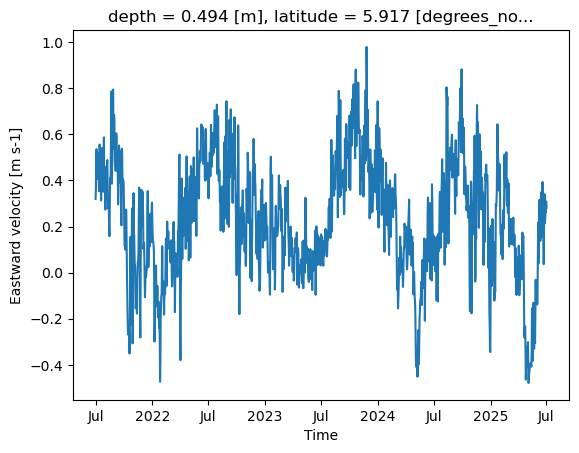

In [12]:
## plotting y velocity at palymra 
palmyra  = funcs.Palmyra_obj()
lat = palmyra.y
print(lat)
lon = palmyra.x
print(lon)

time = uo.sel(latitude = lat, longitude = lon, depth = 1, time = "2021-07-02-16.0:43.5",method = "nearest") 
print(time)
#0.319224
#0.357677
uo.sel(latitude = lat, longitude = lon, depth = 1, method = "nearest").plot()

In [13]:
## lets get time averaged x and y velocity 

vomean = vo.mean(["depth", "time"]).to_numpy()
uomean = uo.mean(["time", "depth"]).to_numpy()
latitude = ds["latitude"].to_numpy()
longitude = ds["longitude"].to_numpy()


Text(0, 0.5, 'Latitude')

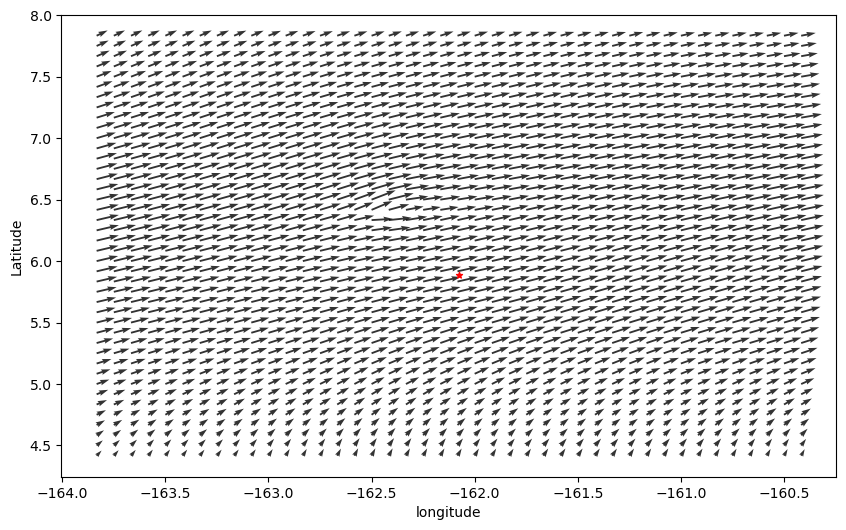

In [14]:
Xcurrents,Ycurrents = np.meshgrid(longitude, latitude)
fig,ax = plt.subplots(figsize = (10,6))
ax.quiver(Xcurrents, Ycurrents,uomean,vomean,scale = 10, alpha = 0.8)
plot.Palmyra_plot(ax)
ax.set_xlabel("longitude")
ax.set_ylabel("Latitude")

In [15]:
xwinds = winds.uo.mean("time")
ywinds = winds.vo.mean("time")
latw = winds.lat
lonw = winds.lon 
XW, YW = np.meshgrid(lonw, latw)

In [16]:
a = 7.73709253e-01+1.62143540e-01j 
b = uo +vo*1j
c = a*b
uo2 = c.real
vo2 = c.imag

In [17]:

umean2 = uo*(a.real*uo - a.imag*vo)
vmean2 = vo*(a.real*vo+uo*a.imag)
umean2 = uo2.mean(['depth', 'time'])
vmean2 = vo2.mean(['depth', 'time'])

c:\FATE\Code\functions\funcs.py:188: RuntimeWarning: divide by zero encountered in divide
  heading = np.atan(delx_long/dely_long)
c:\FATE\Code\functions\funcs.py:188: RuntimeWarning: invalid value encountered in divide
  heading = np.atan(delx_long/dely_long)


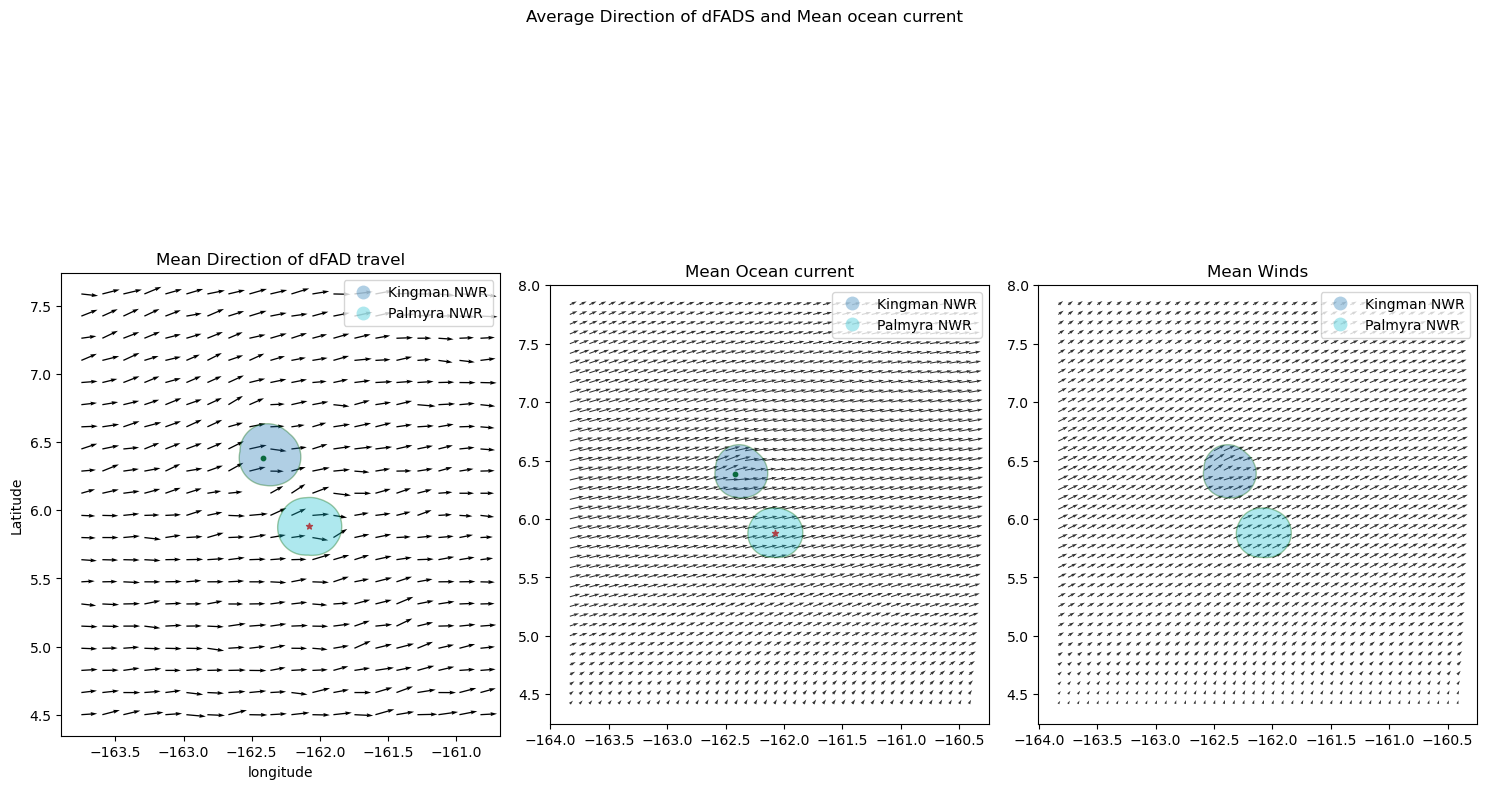

In [18]:
data = gpd.read_parquet(r"Data\Mapped_SAT_MI_Cleanedspeeds.parquet")
dataNWR = gpd.read_file(r"Data\Palmyra_Shapefiles",  layer = 'PAL_KING_NWR_12nm')

data, delx_list, dely_list = funcs.add_distance_collumns(data)
lat, lon = funcs.list_of_latlon(data)

fig, ax = plt.subplots(1,3, figsize = (15,10))
plot.plotting_direction(lat, lon, delx_list=delx_list, dely_list=dely_list, ax = ax[0], scale =15, bins = 20)
ax[1].quiver(Xcurrents, Ycurrents,uomean,vomean,scale = 9, alpha = 0.8)
ax[2].quiver(Xcurrents, Ycurrents,umean2,vmean2,scale = 9, alpha = 0.8)

plot.Palmyra_plot(ax[1])
plot.Palmyra_plot(ax[0])
plot.Kingmon_plt(ax[0])
plot.Kingmon_plt(ax[1])

ax[0].set_title("Mean Direction of dFAD travel")
ax[1].set_title("Mean Ocean current")
ax[2].set_title("Mean Winds")
plot.plot_NWPs(ax[0],dataNWR)
plot.plot_NWPs(ax[1],dataNWR)
plot.plot_NWPs(ax[2],dataNWR)
#ax[0,0].set_xlabel("longitude")
#ax[1,0].set_ylabel("Latitude")
fig.suptitle("Average Direction of dFADS and Mean ocean current")
fig.tight_layout()
fig.savefig(r"C:\FATE\Figures\Direction_meanocean_2.png")

### Plotting cmems movies of mean monthly currents over tropical pacific 6s - 8N, 

In [19]:
import matplotlib.animation as animation
import functions.plotting as plot 
from matplotlib import cm, colors
cmems = xr.open_dataset(r'Data\cmems_monthly.nc')
krig = xr.open_dataset(r"Data\krigging_field.nc")
climat = xr.open_dataset(r"Data\drifter_monthlymeans.nc")
climat = climat.rename({"latitude" : "lat", "longitude": "lon", "U": "uo", "V": "vo"})


cmems2023 = cmems.sel(time = slice("2023-01-01", "2024-01-01"), depth = 13.46714)
cmems2024 = cmems.sel(time = slice("2024-01-01", "2025-01-01"), depth = 13.46714)
cmems2022 = cmems.sel(time = slice("2022-01-01", "2023-01-01"), depth = 13.46714)
krig2022 = krig.sel(time = slice("2022-01-01", "2023-01-01"))
krig2023 = krig.sel(time = slice("2023-01-01", "2024-01-01"))
krig2024 = krig.sel(time = slice("2024-01-01", "2025-01-01"))

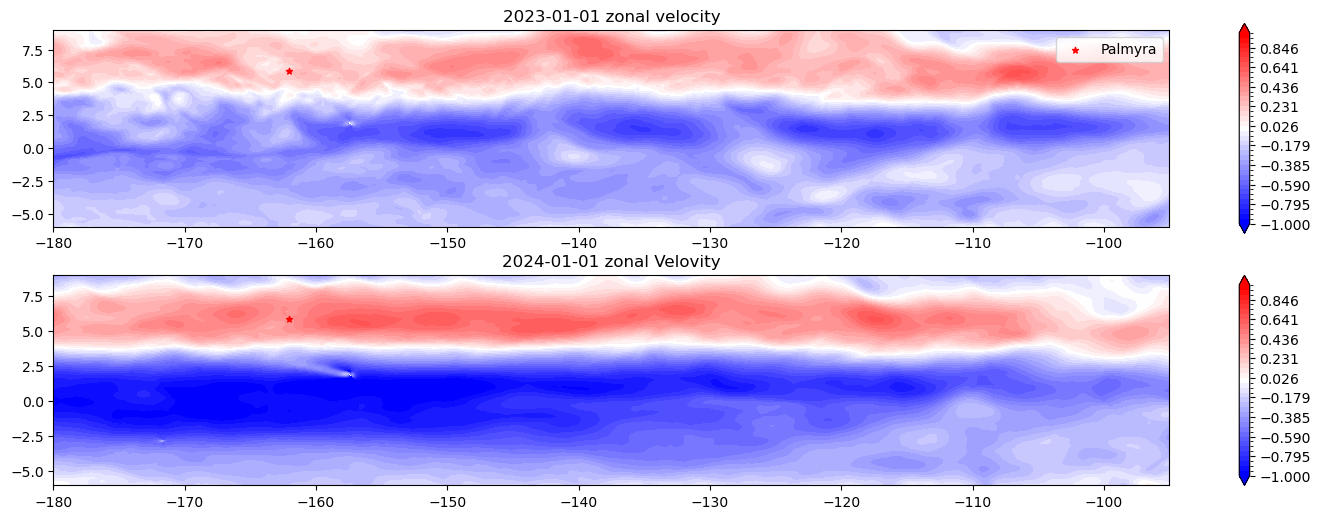

In [20]:
fig, ax = plt.subplots(2,1,figsize = (18,6))
x = cmems2023.longitude.to_numpy()
y = cmems2023.latitude.to_numpy()
X,Y = np.meshgrid(x,y)
# plot = ax.contourf(X,Y,cmems2023.uo[4,:,:] )
ax[0].set_aspect("equal")
#fig.colorbar(plot)
vmin, vmax = -1, 1 # Ensure consistent color mapping across frames
levels = np.linspace(vmin, vmax, 40)
cmap = cm.bwr
norm = colors.BoundaryNorm(levels, cmap.N)
cbar1 = ax[0].contourf(X,Y,cmems2023.uo[0,:,:], levels =levels , cmap = cmap, norm = norm, extend = "both")
cbar2 = ax[1].contourf(X,Y,cmems2024.uo[0,:,:], levels =levels , cmap = cmap, norm = norm, extend = "both")

def update(frame):
    ax[0].clear()
    contour_plot = ax[0].contourf(X,Y,cmems2023.uo[frame,:,:], levels =levels, cmap =cmap, norm = norm , extend = "both")
    contour_plot = ax[1].contourf(X,Y,cmems2024.uo[frame,:,:], levels =levels, cmap =cmap, norm = norm ,extend = "both")
    date = cmems2023.time[frame].values
    date = pd.to_datetime(date).date()
    date2 = cmems2024.time[frame].values
    date2 = pd.to_datetime(date2).date()

    ax[0].set_title(f" {date}")
    plot.Palmyra_plot(ax[0])
    plot.Palmyra_plot(ax[1])
    ax[0].legend()
    ax[0].set_title(f'{date} zonal velocity')
    ax[1].set_title(f"{date2} zonal Velovity")
nframes = cmems2023.uo.shape[0]
cbar1 = fig.colorbar(cbar1)
cbar2 = fig.colorbar(cbar2)
#plot.Palmyra_plot(ax)


ani = animation.FuncAnimation(fig, update, frames =nframes, interval = 500, blit = False)
#ani.save("cmems_2023vs2024_animation.mp4", writer= 'ffmpeg')


In [21]:
krig_month2022 = krig2022.groupby("time.month").mean("time").rename({"month": "time"})
krig_month2023 = krig2023.groupby("time.month").mean("time").rename({"month": "time"})
krig_month2024 = krig2024.groupby("time.month").mean("time").rename({"month": "time"})

In [22]:
## CalculaTE monthly/seasonally direction that dFADs are traveling, Bined by latitude 
longlist = pd.DataFrame()
longlist['time'] = funcs.Column_to_List(data, 'TimeStamp')
longlist['x_speed'] = funcs.Column_to_List(data, 'x_speed')
longlist['y_speed'] = funcs.Column_to_List(data, 'y_speed')
longlist['lat'], longlist['lon'] = funcs.list_of_latlon(data, False)
longlist['time'] = pd.to_datetime(longlist.time)
## Group by season and take average U_speed of lat profile 
longlist['year'] = longlist.time.dt.year
longlist['month'] = longlist.time.dt.month
month_bins = np.array([1,4,7,10,13])
longlist['season'] = pd.cut(longlist['month'], month_bins, right = False) # makes it [a,b) months 1-3, 4-6,7-9, 10-12
lat_bins = np.arange(4.5,8.01, 0.50)
print(lat_bins)
longlist['lat_bin'] = pd.cut(longlist.lat, lat_bins, right = False)

[4.5 5.  5.5 6.  6.5 7.  7.5 8. ]


In [23]:
def calc_lat_average(longlist):
    profiles = pd.DataFrame()
    for n, bin in enumerate(longlist.season.unique().dropna().sort_values()):
        season = longlist[longlist['season'] == bin]
        profile =season.groupby('lat_bin', observed=False)['x_speed'].mean()
        profiles[n+1] = profile
    profiles = profiles.reset_index()
    profiles['lat'] = lat_bins[profiles.index] + np.diff(lat_bins)/2
    return profiles

longlist2022 = longlist[longlist['year'] == 2022]
longlist2023 = longlist[longlist['year'] == 2023]
longlist2024 = longlist[longlist['year'] == 2024]
profiles2022 = calc_lat_average(longlist2022)
profiles2023 = calc_lat_average(longlist2023)
profiles2024 = calc_lat_average(longlist2024)
profiles = calc_lat_average(longlist)


In [24]:
from Sverdrup import Calc_sverdrup
wind = xr.open_dataset(r'Data\ERA5_10m_winds.nc')
wind = wind.sortby('lat')
wind2022 = wind.sel(time = slice('2022-01-01', '2023-01-01'))
wind2023 = wind.sel(time = slice('2023-01-01', '2024-01-01'))
wind2024 = wind.sel(time = slice('2024-01-01', '2025-01-01'))

(13, 85)
0
3
3
6
6
9
9
12


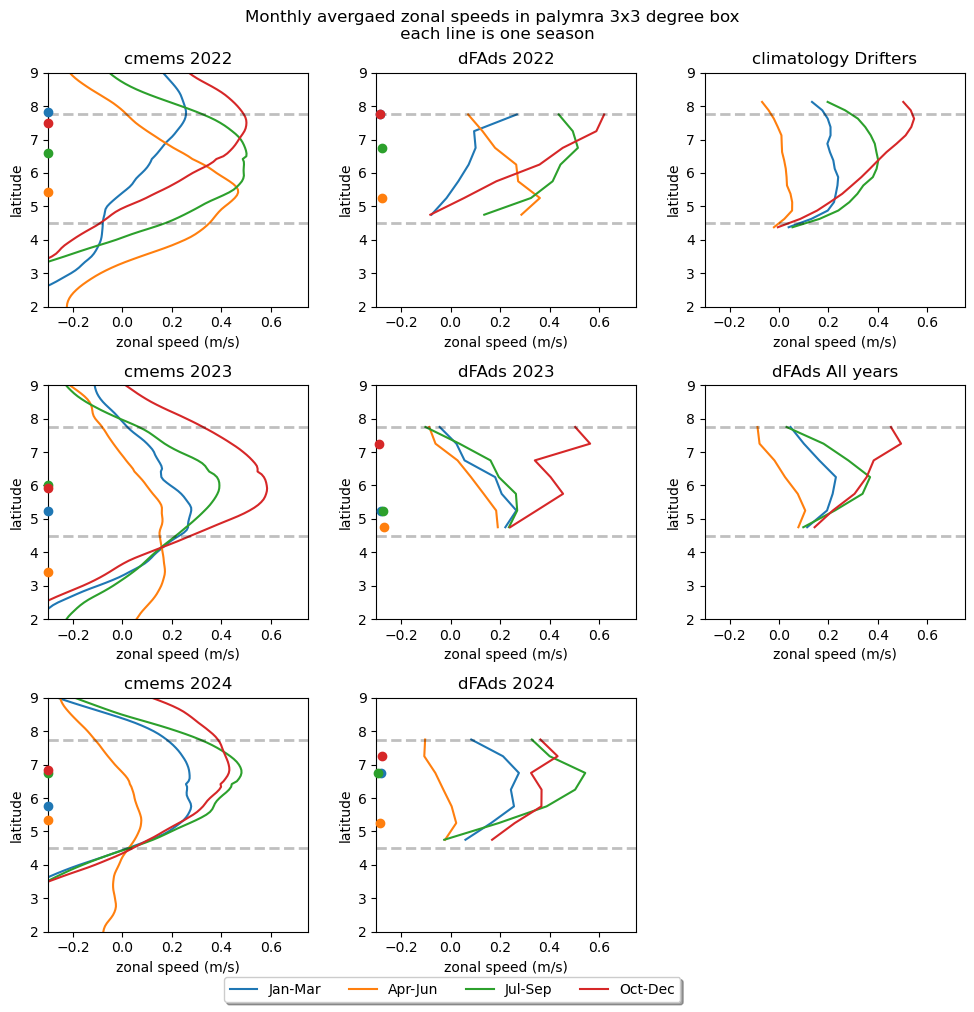

In [32]:
### Taking longitude average over our 3 degree box 
upperlat = 9
box = cmems2022.sel(latitude = slice(2, upperlat), longitude = slice(-163.75, -160.5))
box = box.mean(dim = "longitude")
box2 =cmems2023.sel(latitude = slice(2,upperlat), longitude = slice(-163.74, -160.5))
box2 = box2.mean(dim = "longitude")
box3 =cmems2024.sel(latitude = slice(2,upperlat), longitude = slice(-163.74, -160.5))
box3 = box3.mean(dim = "longitude")

box4 = krig_month2022.sel(lat = slice(2, upperlat), lon = slice(-163.75, -160.5))
box4 = box4.mean(dim = "lon")
box5 = krig_month2023.sel(lat = slice(2, upperlat), lon = slice(-163.75, -160.5))
box5 = box5.mean(dim = "lon")
box6 = krig_month2024.sel(lat = slice(2, upperlat), lon = slice(-163.75, -160.5))
box6 = box6.mean(dim = "lon")

box7 = climat.sel(lat = slice(2, upperlat), lon = slice(-163.75, -160.5))
box7 = box7.mean(dim = "lon")
box8 = climat.sel(lat = slice(2, upperlat), lon = slice(-163.75, -160.5))
box8 = box8.mean(dim = "lon")
box9 = climat.sel(lat = slice(2, upperlat), lon = slice(-163.75, -160.5))
box9 = box9.mean(dim = "lon")




print(box.uo.shape)
fig = plt.figure(figsize= (10,10))
gs = fig.add_gridspec(3,3)
ax00 = fig.add_subplot(gs[0,0])
ax01 = fig.add_subplot(gs[0,1])
ax10 = fig.add_subplot(gs[1,0])
ax20 = fig.add_subplot(gs[2,0])
ax21 = fig.add_subplot(gs[2,1])
ax11 = fig.add_subplot(gs[1,1])
ax12 = fig.add_subplot(gs[1,2])
ax02 = fig.add_subplot(gs[0,2])
#Sverdrop
# ax03 = fig.add_subplot(gs[0,3])
# ax13 = fig.add_subplot(gs[1,3])
# ax23 = fig.add_subplot(gs[2,3])
#axlist = [ax00, ax10, ax20, ax01, ax11, ax21, ax02, ax12, ax03, ax13, ax23]
axlist = [ax00, ax10, ax20, ax01, ax11, ax21, ax02, ax12]

months =['-01-01', '-04-01', '-07-01', '-10-01', '-12-31']
labels = ['Jan-Mar', 'Apr-Jun', 'Jul-Sep', 'Oct-Dec']
for i in range(4): ## for 4 seasons
    print(i*3)
    print((i+1)*3)
    ax00.plot(box.uo[i*3:(i+1)*3,:].mean(dim = "time"), box.latitude, label = labels[i]) #f"{1+i*3} - {(i+1)*3}
    ax10.plot(box2.uo[i*3:(i+1)*3,:].mean(dim = "time"), box2.latitude)
    ax20.plot(box3.uo[i*3:(i+1)*3,:].mean(dim = "time"), box2.latitude)

    ax01.plot(profiles2022[i+1], profiles2022.lat)
    ax11.plot(profiles2023[i+1], profiles2023.lat)
    ax21.plot(profiles2024[i+1], profiles2024.lat)
    ## Turn on for krigign 
    # ax01.plot(box4.uo[i*3:(i+1)*3,:].mean(dim = "time"), box4.lat)
    # ax11.plot(box5.uo[i*3:(i+1)*3,:].mean(dim = "time"), box5.lat)
    # ax21.plot(box6.uo[i*3:(i+1)*3,:].mean(dim = "time"), box6.lat)

    ax02.plot(box7.uo[i*3:(i+1)*3,:].mean(dim = "ClimatologicalMonth"), box7.lat)
    ax12.plot(profiles[i+1], profiles.lat)

    # windi = wind2022.sel(time = slice('2022'+months[i], '2022' +months[i+1])).mean(dim = 'time')
    # U = Calc_sverdrup(windi)
    # ax03.plot(U, U.lat)

    # windi = wind2023.sel(time = slice('2023'+months[i], '2023' +months[i+1])).mean(dim = 'time')
    # U = Calc_sverdrup(windi)
    # ax13.plot(U, U.lat)

    # windi = wind2024.sel(time = slice('2024'+months[i], '2024' +months[i+1])).mean(dim = 'time')
    # U = Calc_sverdrup(windi)
    # ax23.plot(U, U.lat)

    ax00.scatter(-0.3,box.uo[i*3:(i+1)*3,:].mean(dim = "time").idxmax(), marker = "o", clip_on = False, zorder = 100)
    ax10.scatter(-0.3,box2.uo[i*3:(i+1)*3,:].mean(dim = "time").idxmax(), marker = "o", clip_on = False, zorder = 100)
    ax20.scatter(-0.3,box3.uo[i*3:(i+1)*3,:].mean(dim = "time").idxmax(), marker = "o", clip_on = False, zorder = 100)

    ax01.scatter(-0.3+np.random.random(1)*0.03,profiles2022.iloc[profiles2022[i+1].idxmax()].lat, marker = "o", clip_on = False, zorder = 100)
    ax11.scatter(-0.3+np.random.random(1)*0.03,profiles2023.iloc[profiles2023[i+1].idxmax()].lat, marker = "o", clip_on = False, zorder = 100)
    ax21.scatter(-0.3+np.random.random(1)*0.03,profiles2024.iloc[profiles2024[i+1].idxmax()].lat, marker = "o", clip_on = False, zorder = 100)
    # ax01.scatter(-0.3,box4.uo[i*3:(i+1)*3,:].mean(dim = "time").idxmax(), marker = "o", clip_on = False, zorder = 100)
    # ax11.scatter(-0.3,box5.uo[i*3:(i+1)*3,:].mean(dim = "time").idxmax(), marker = "o", clip_on = False, zorder = 100)
    # ax21.scatter(-0.3,box6.uo[i*3:(i+1)*3,:].mean(dim = "time").idxmax(), marker = "o", clip_on = False, zorder = 100)

titles = ["cmems 2022", "cmems 2023", "cmems 2024", "dFAds 2022", "dFAds 2023", "dFAds 2024", "climatology Drifters", "dFAds All years", "Sverdrup 2022", "Sverdrup 2023", "Sverdrup 2024"]

# Sv_ax = [ax03,ax13, ax23]
for t, ax in enumerate(axlist): 
    #ax.vlines(0, 2,9, color = "k", ls = '--', lw = 2, alpha = 0.25)
    # if ax in Sv_ax:
    #     ax.hlines([4.5, 7.75],-40, 60 ,color = "k", ls = '--', lw = 2, alpha = 0.25 )
    #     ax.set(xlim = [-20, 60],ylim = [2,upperlat], xlabel = "zonal Transport (m^2/s)", ylabel = "latitude", title = titles[t])
    #     continue
    ax.hlines([4.5, 7.75],-0.3, 0.75 ,color = "k", ls = '--', lw = 2, alpha = 0.25 )
    ax.set(xlim = [-0.3, 0.75],ylim = [2,upperlat], xlabel = "zonal speed (m/s)", ylabel = "latitude", title = titles[t])

fig.suptitle("Monthly avergaed zonal speeds in palymra 3x3 degree box \n each line is one season")
fig.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.02),
          fancybox=True, shadow=True, ncol=6)
fig.tight_layout()

In [26]:
profiles2022[1].idxmax()
profiles2022.iloc[6]

lat_bin    [7.5, 8.0)
1            0.267399
2            0.070403
3            0.436816
4            0.620618
lat              7.75
Name: 6, dtype: object

In [27]:
### Regridding wind onto cmems data to be mapped together
windsr = winds.rename({'lat': 'latitude' ,'lon' : 'longitude'})
ds_interp = windsr.interp_like(ds)

In [28]:
ds_interp = windsr.interp_like(ds)
